# Implied volatility and the volatility surface

Phases 1 and 2 assumed volatility $\sigma$ is a known constant. This notebook inverts the BSM formula to back out the volatility implied by each market price, the **implied volatility (IV)**.

If BSM were a perfect model, implied volatility would be identical across all strikes and expiries for the same underlying. In practice it varies and produces the **volatility surface**.

This notebook covers:
- Inverting BSM numerically using Newton-Raphson and bisection
- Pulling real option chain data from Yahoo Finance
- Computing implied volatility across strikes and expiries
- Visualizing and interpreting the volatility surface
- Understanding what the shape of the surface tells us about market expectations

## Part 1: implied volatility

### The concept

BSM maps five inputs to a price:

$$(S, K, T, r, \sigma) \rightarrow \text{price}$$

Implied volatility is the $\sigma$ that makes BSM reproduce an observed market price:

$$(\text{market price}, S, K, T, r) \rightarrow \sigma_{implied}$$

This requires solving:

$$g(\sigma) = \text{BSM}(\sigma) - \text{market price} = 0$$

Since BSM has no closed-form inverse, $\sigma_{implied}$ must be found numerically.
The function $g$ is well-behaved for this purpose:
- Strictly monotone — BSM price always increases with $\sigma$ (vega > 0 always), 
  so there is at most one solution
- Bounded — $\sigma$ must be positive, and BSM price approaches the stock price 
  as $\sigma \to \infty$

### Newton-Raphson

Newton-Raphson iterates toward the root by following the tangent line at each step:

$$\sigma_{n+1} = \sigma_n - \frac{g(\sigma_n)}{g'(\sigma_n)} = \sigma_n - \frac{\text{BSM}(\sigma_n) - \text{market price}}{\text{vega}(\sigma_n)}$$

Since $g'(\sigma) = \frac{d(\text{BSM price})}{d\sigma} = \text{vega}$, we already have the derivative from Phase 1. 

### Bisection

Bisection brackets the root between a low and high sigma and repeatedly halves 
the interval:

- $g(\sigma_{low}) < 0$ and $g(\sigma_{high}) > 0$ guarantees a root exists between them
- Each iteration halves the interval: after $n$ steps, error $\leq \frac{5}{2^n}$
- After 30 iterations: error $\approx 5 \times 10^{-9}$ — essentially machine precision

Bisection is slower than Newton-Raphson but guaranteed to converge. The combined 
solver tries Newton-Raphson first and falls back to bisection if it fails.

### No-arbitrage bounds

Not all market prices have a valid implied volatility. A call price must satisfy:

$$C \geq S - Ke^{-rT}$$

This is tighter than the raw intrinsic value $S - K$ because you could invest 
$Ke^{-rT}$ today and grow it to $K$ at expiry. 
If a market price violates this bound, the solver returns `None` and the option 
is excluded from the surface. In practice this filters out stale quotes, illiquid 
options, and data errors from yfinance.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import yfinance as yf
import warnings
import sys
sys.path.append('..')
warnings.filterwarnings('ignore')

from src.black_scholes import bsm_price
from src.implied_vol import implied_vol, implied_vol_newton, implied_vol_bisection
from src.greeks import vega

#3 month risk-free rate
r = 0.0376

## Part 2: solver verification

Before using real market data, verify the solvers recover known implied 
volatilities from synthetic BSM prices.

In [27]:
S, K, T = 100, 100, 1.0
true_vols = [0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.80]

print("Round-trip test — recover sigma from BSM price")
print(f"{'True sigma':>12} | {'NR sigma':>12} | {'Bisect sigma':>12} | "
      f"{'NR error':>12} | {'Bisect error':>12} | {'Agree':>8}")
print("-" * 80)

for true_sigma in true_vols:
    price  = bsm_price(S, K, T, r, true_sigma, "call")
    iv_nr  = implied_vol_newton(price, S, K, T, r)
    iv_bis = implied_vol_bisection(price, S, K, T, r)
    nr_err  = abs(iv_nr  - true_sigma) if iv_nr  is not None else float('nan')
    bis_err = abs(iv_bis - true_sigma) if iv_bis is not None else float('nan')
    agree   = abs(iv_nr - iv_bis) < 1e-4 if (iv_nr and iv_bis) else False
    print(f"{true_sigma:>12.4f} | {iv_nr:>12.6f} | {iv_bis:>12.6f} | "
          f"{nr_err:>12.2e} | {bis_err:>12.2e} | {str(agree):>8}")

Round-trip test — recover sigma from BSM price
  True sigma |     NR sigma | Bisect sigma |     NR error | Bisect error |    Agree
--------------------------------------------------------------------------------
      0.1000 |     0.100000 |     0.100000 |     1.76e-12 |     5.96e-09 |     True
      0.1500 |     0.150000 |     0.150000 |     1.06e-08 |     1.34e-09 |     True
      0.2000 |     0.200000 |     0.200000 |     0.00e+00 |     3.28e-09 |     True
      0.3000 |     0.300000 |     0.300000 |     1.01e-09 |     1.25e-08 |     True
      0.4000 |     0.400000 |     0.400000 |     7.37e-09 |     2.18e-08 |     True
      0.5000 |     0.500000 |     0.500000 |     2.07e-09 |     6.24e-09 |     True
      0.8000 |     0.800000 |     0.800000 |     8.89e-12 |     1.58e-08 |     True


In [28]:
import time

price = bsm_price(100, 100, 1, r, 0.20, "call")
n_trials = 10000

start = time.perf_counter()
for _ in range(n_trials):
    implied_vol_newton(price, 100, 100, 1, r)
nr_time = (time.perf_counter() - start) * 1000

start = time.perf_counter()
for _ in range(n_trials):
    implied_vol_bisection(price, 100, 100, 1, r)
bis_time = (time.perf_counter() - start) * 1000

print(f"Newton-Raphson: {nr_time:.1f}ms for {n_trials} solves "
      f"({nr_time/n_trials*1000:.2f} μs each)")
print(f"Bisection:      {bis_time:.1f}ms for {n_trials} solves "
      f"({bis_time/n_trials*1000:.2f} μs each)")
print(f"Speedup:        {bis_time/nr_time:.1f}x faster with Newton-Raphson")

Newton-Raphson: 647.1ms for 10000 solves (64.71 μs each)
Bisection:      16061.6ms for 10000 solves (1606.16 μs each)
Speedup:        24.8x faster with Newton-Raphson


### Convergence comparison: Newton-Raphson vs bisection

The two solvers reach the same answer but through  different convergence behavior.

**Newton-Raphson** converges quadratically, each iteration roughly squares 
the error. Once it gets close to the solution, the remaining error drops 
from $10^{-3}$ to $10^{-6}$ to $10^{-12}$ in just three more steps. This 
is why it typically converges in 4-6 iterations regardless of tolerance.

**Bisection** converges linearly, each iteration halves the error. The 
error decreases by a fixed factor of 0.5 per step, so reaching $10^{-6}$ 
precision from an initial interval of width 5.0 requires:

$$n = \log_2\left(\frac{5.0}{10^{-6}}\right) \approx 23 \text{ iterations}$$

Hence, we plot the convergence of the two difference methods.

True sigma: 0.25, Market price: $11.7188

Newton-Raphson (4 iterations to converge):
  Iter |        Sigma |          Error |     Price diff
------------------------------------------------------
     0 |   0.20000000 |       5.00e-02 |       1.92e+00
     1 |   0.25010916 |       1.09e-04 |       4.19e-03
     2 |   0.25000000 |       1.66e-10 |       6.38e-09
     3 |   0.25000000 |       3.33e-16 |       7.11e-15

Bisection (39 iterations to converge):
  Iter |        Sigma |          Error |     Price diff
------------------------------------------------------
     0 |   2.50005000 |       2.25e+00 |       6.75e+01
     1 |   1.25007500 |       1.00e+00 |       3.61e+01
     2 |   0.62508750 |       3.75e-01 |       1.43e+01
     3 |   0.31259375 |       6.26e-02 |       2.40e+00
     4 |   0.15634687 |       9.37e-02 |       3.58e+00
     5 |   0.23447031 |       1.55e-02 |       5.96e-01
     6 |   0.27353203 |       2.35e-02 |       9.04e-01
     7 |   0.25400117 |       4.00e-0

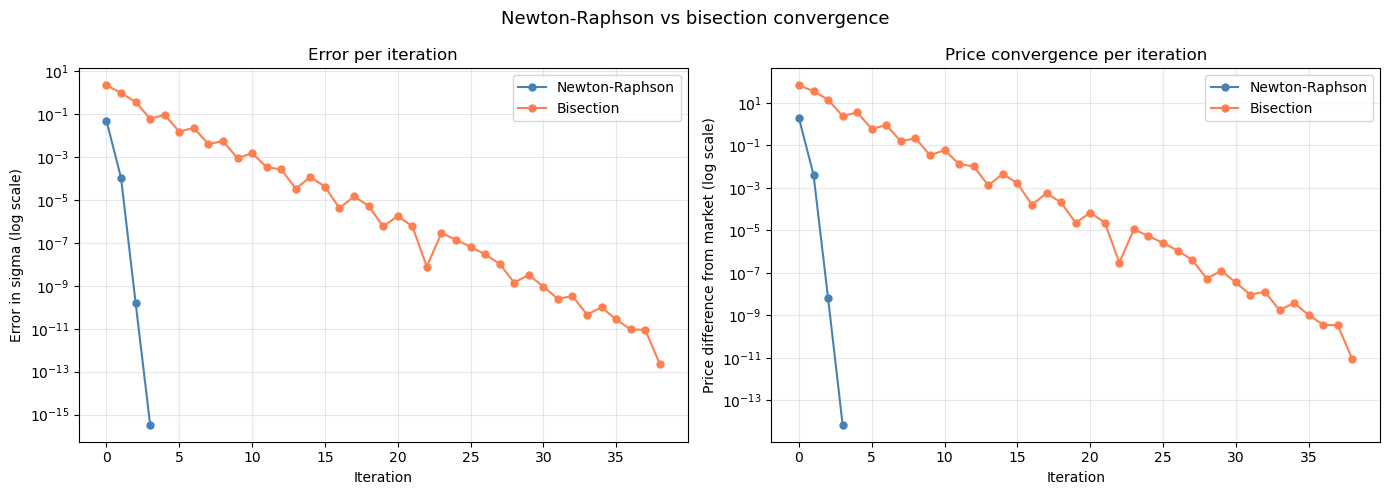

In [29]:
true_sigma   = 0.25
market_price = bsm_price(S, K, T, r, true_sigma, "call")

# --- Newton-Raphson convergence trace ---
nr_trace = []
sigma    = 0.20  # initial guess

for i in range(20):
    price = bsm_price(S, K, T, r, sigma, "call")
    diff  = price - market_price
    v     = vega(S, K, T, r, sigma) / 0.01
    nr_trace.append({
        "iteration": i,
        "sigma":     sigma,
        "error":     abs(sigma - true_sigma),
        "price_diff": abs(diff)
    })
    if abs(diff) < 1e-10:
        break
    if abs(v) < 1e-10:
        break
    sigma = sigma - diff / v

# --- Bisection convergence trace ---
bis_trace  = []
sigma_low  = 1e-4
sigma_high = 5.0

for i in range(50):
    sigma_mid = (sigma_low + sigma_high) / 2
    price_mid = bsm_price(S, K, T, r, sigma_mid, "call")
    diff      = price_mid - market_price
    bis_trace.append({
        "iteration": i,
        "sigma":     sigma_mid,
        "error":     abs(sigma_mid - true_sigma),
        "price_diff": abs(diff)
    })
    if abs(diff) < 1e-10:
        break
    if diff > 0:
        sigma_high = sigma_mid
    else:
        sigma_low  = sigma_mid

nr_df  = pd.DataFrame(nr_trace)
bis_df = pd.DataFrame(bis_trace)

# --- Print convergence tables ---
print(f"True sigma: {true_sigma}, Market price: ${market_price:.4f}")
print(f"\nNewton-Raphson ({len(nr_df)} iterations to converge):")
print(f"{'Iter':>6} | {'Sigma':>12} | {'Error':>14} | {'Price diff':>14}")
print("-" * 54)
for _, row in nr_df.iterrows():
    print(f"{int(row['iteration']):>6} | {row['sigma']:>12.8f} | "
          f"{row['error']:>14.2e} | {row['price_diff']:>14.2e}")

print(f"\nBisection ({len(bis_df)} iterations to converge):")
print(f"{'Iter':>6} | {'Sigma':>12} | {'Error':>14} | {'Price diff':>14}")
print("-" * 54)
for _, row in bis_df.iterrows():
    print(f"{int(row['iteration']):>6} | {row['sigma']:>12.8f} | "
          f"{row['error']:>14.2e} | {row['price_diff']:>14.2e}")

# --- Plot convergence ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Newton-Raphson vs bisection convergence", fontsize=13)

axes[0].semilogy(nr_df["iteration"],  nr_df["error"],
                  color="steelblue", marker="o", markersize=5,
                  label="Newton-Raphson", linewidth=1.5)
axes[0].semilogy(bis_df["iteration"], bis_df["error"],
                  color="coral",     marker="o", markersize=5,
                  label="Bisection",       linewidth=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Error in sigma (log scale)")
axes[0].set_title("Error per iteration")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogy(nr_df["iteration"],  nr_df["price_diff"],
                  color="steelblue", marker="o", markersize=5,
                  label="Newton-Raphson", linewidth=1.5)
axes[1].semilogy(bis_df["iteration"], bis_df["price_diff"],
                  color="coral",     marker="o", markersize=5,
                  label="Bisection",       linewidth=1.5)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Price difference from market (log scale)")
axes[1].set_title("Price convergence per iteration")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("solver_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 3: real market data

We now pull real option chain data from Yahoo Finance and compute implied 
volatility for each option. The ticker used here is SPY (S&P 500 ETF).

The risk-free rate is approximated using the 13-week US Treasury bill yield (^IRX), 
pulled live from Yahoo Finance. However, it has some limitations. It applies a single rate across all expiries, so the 13-week rate is appropriate for near-term options but understates the correct discount rate for longer-dated expiries where the yield curve may be different.

Several filters are applied to ensure data quality:
- Options with zero volume or open interest are excluded — these are illiquid 
  and their prices may not reflect true market consensus
- Options violating no-arbitrage bounds are excluded — stale or erroneous quotes
- Options with very short expiry (T < 7 days) are excluded — gamma explosion 
  near expiry distorts the surface
- Only options with moneyness between 0.7 and 1.3 are included — far 
  out-of-the-money options are illiquid and their implied vols are unreliable

In [30]:
ticker = "SPY"
stock  = yf.Ticker(ticker)

# current spot price
S = stock.history(period="1d")["Close"].iloc[-1]
print(f"{ticker} spot price: ${S:.2f}")

# available expiry dates
expiries = stock.options
print(f"\nAvailable expiries ({len(expiries)} total):")
for exp in expiries[:10]:  # show first 10
    print(f"  {exp}")


# risk-free rate from 13-week T-bill yield
tbill = yf.Ticker("^IRX")
r     = tbill.history(period="1d")["Close"].iloc[-1] / 100
print(f"Risk-free rate (13-week T-bill): {r*100:.3f}%")

SPY spot price: $744.78

Available expiries (34 total):
  2026-07-06
  2026-07-07
  2026-07-08
  2026-07-09
  2026-07-10
  2026-07-13
  2026-07-14
  2026-07-15
  2026-07-16
  2026-07-17
Risk-free rate (13-week T-bill): 3.668%


In [31]:
from datetime import datetime

records = []

for expiry in expiries:
    # compute time to expiry in years
    T = (datetime.strptime(expiry, "%Y-%m-%d") - datetime.today()).days / 365

    if T < 7/365:
        continue  # skip near-expiry options

    chain = stock.option_chain(expiry)

    for option_type, df in [("call", chain.calls), ("put", chain.puts)]:
        for _, row in df.iterrows():
            K           = row["strike"]
            mid_price   = (row["bid"] + row["ask"]) / 2
            volume      = row["volume"]
            open_int    = row["openInterest"]
            moneyness   = K / S

            # liquidity filter
            if pd.isna(volume) or pd.isna(open_int):
                continue
            if volume < 1 or open_int < 1:
                continue

            # moneyness filter — keep near-the-money options only
            if moneyness < 0.7 or moneyness > 1.3:
                continue

            # price sanity check
            if pd.isna(mid_price) or mid_price <= 0:
                continue

            iv = implied_vol(mid_price, S, K, T, r, option_type)

            if iv is None or iv < 0.01 or iv > 5.0:
                continue

            records.append({
                "expiry":      expiry,
                "T":           T,
                "K":           K,
                "moneyness":   moneyness,
                "option_type": option_type,
                "mid_price":   mid_price,
                "volume":      volume,
                "open_interest": open_int,
                "iv":          iv
            })

df_iv = pd.DataFrame(records)
print(f"Total options processed: {len(df_iv)}")
print(f"Expiries with data:      {df_iv['expiry'].nunique()}")
print(f"\nImplied vol summary:")
print(df_iv["iv"].describe())

Total options processed: 5874
Expiries with data:      27

Implied vol summary:
count    5874.000000
mean        0.208102
std         0.072756
min         0.101769
25%         0.153911
50%         0.197279
75%         0.242967
max         0.781005
Name: iv, dtype: float64


## Part 4: the volatility smile and skew


### Why the skew exists for equity options

Equity options typically show a negative skew. Lower strikes have higher implied vol than higher strikes. It reflects two phenomena:

**1. Crash risk / fat tails**

Real stock returns have fatter tails than the lognormal distribution BSM assumes. 
Large downward moves happen more frequently than BSM predicts. Traders price this 
in by paying more for downside puts (low strikes), pushing their implied vols higher.

**2. Leverage effect**

When stock prices fall, companies become more leveraged (debt stays fixed while 
equity value drops), making equity inherently more volatile. This means volatility 
and price are negatively correlated in practice.

### The volatility surface

Plotting IV across both strikes and expiries gives the full volatility surface. 
Its shape encodes market expectations about:
- Near-term vs long-term uncertainty (term structure)
- Tail risk at different strikes (skew)
- Overall level of market fear (VIX is essentially the ATM point on this surface)

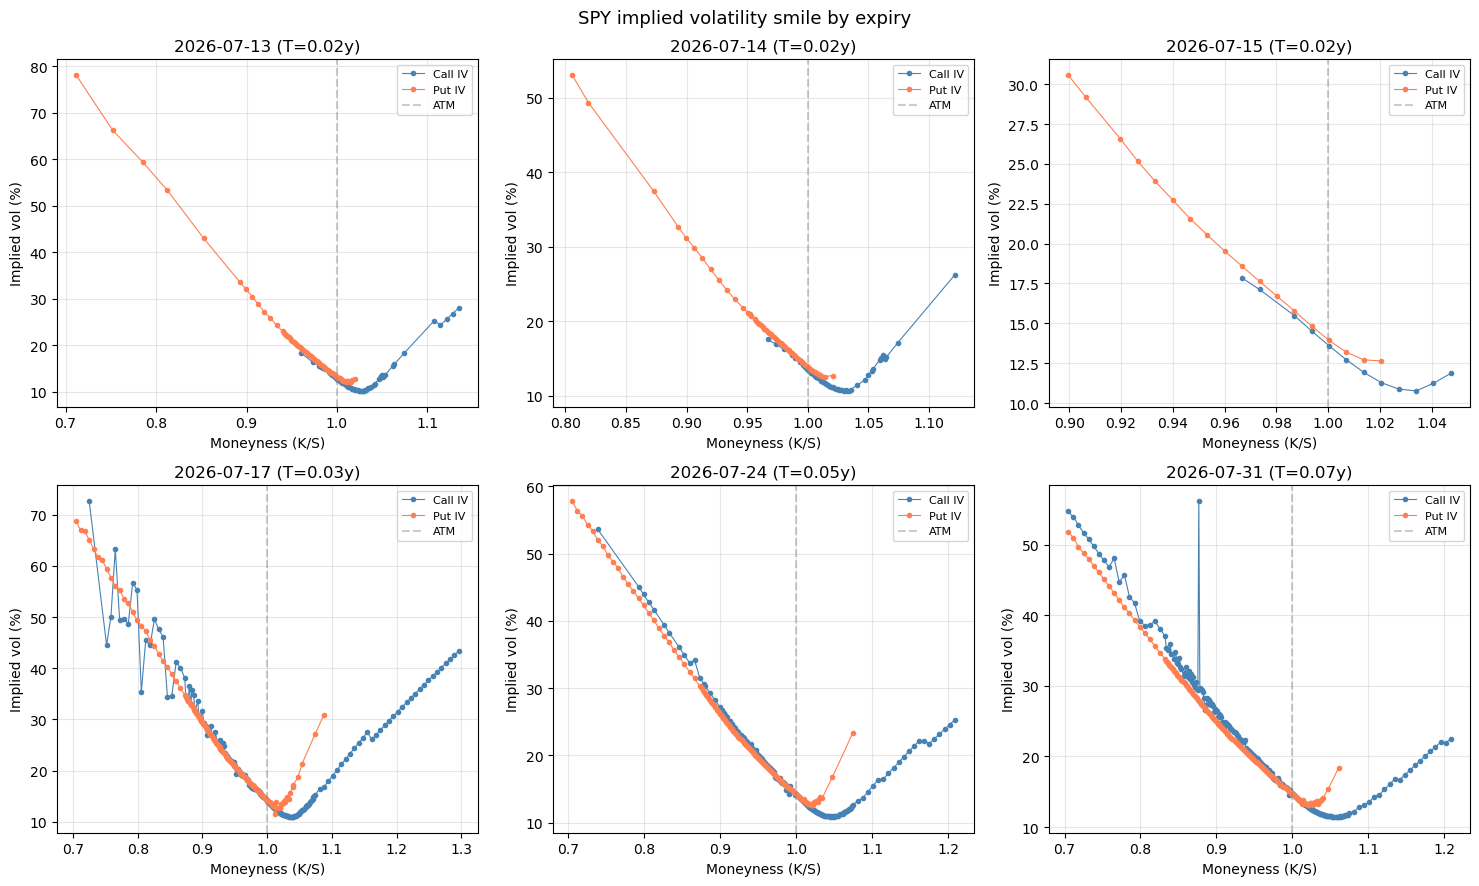

In [32]:
# select a few expiries to compare smiles
expiry_list = df_iv["expiry"].unique()
selected    = expiry_list[:6]  # first 6 expiries

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(f"{ticker} implied volatility smile by expiry", fontsize=13)
axes = axes.flatten()

for i, expiry in enumerate(selected):
    subset = df_iv[df_iv["expiry"] == expiry]
    calls  = subset[subset["option_type"] == "call"].sort_values("moneyness")
    puts   = subset[subset["option_type"] == "put"].sort_values("moneyness")
    T_val  = subset["T"].iloc[0]

    axes[i].plot(calls["moneyness"], calls["iv"] * 100,
                 color="steelblue", marker="o", markersize=3,
                 linewidth=0.8, label="Call IV")
    axes[i].plot(puts["moneyness"],  puts["iv"]  * 100,
                 color="coral",     marker="o", markersize=3,
                 linewidth=0.8, label="Put IV")
    axes[i].axvline(1.0, color="gray", linestyle="--", alpha=0.4, label="ATM")
    axes[i].set_title(f"{expiry} (T={T_val:.2f}y)")
    axes[i].set_xlabel("Moneyness (K/S)")
    axes[i].set_ylabel("Implied vol (%)")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("vol_smile.png", dpi=150, bbox_inches="tight")
plt.show()

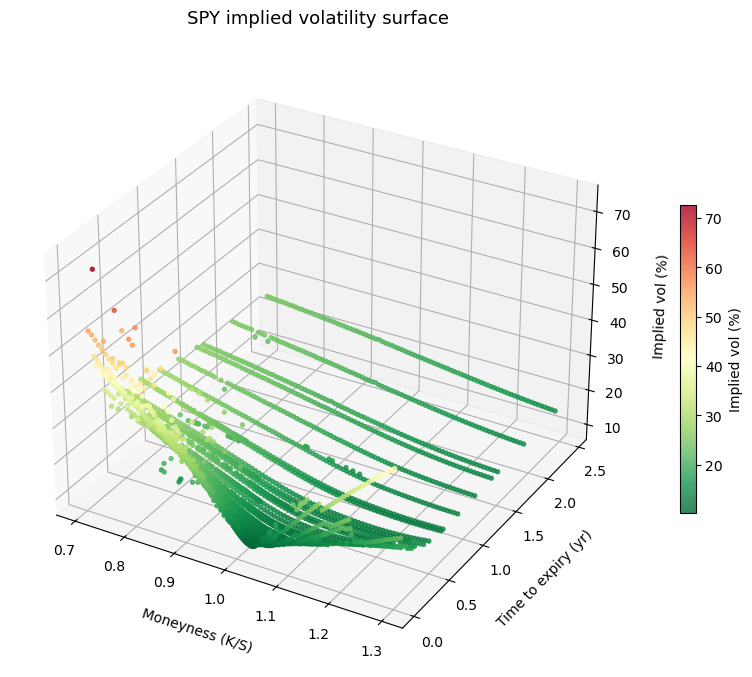

In [33]:
# use calls only for a cleaner surface
calls_only = df_iv[df_iv["option_type"] == "call"].copy()

# pivot to a grid for surface plotting
calls_only["T_round"] = calls_only["T"].round(3)
surface = calls_only.groupby(["moneyness", "T_round"])["iv"].median().reset_index()

fig = plt.figure(figsize=(14, 8))
ax  = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    surface["moneyness"],
    surface["T_round"],
    surface["iv"] * 100,
    c=surface["iv"] * 100,
    cmap="RdYlGn_r",
    s=8,
    alpha=0.8
)

ax.set_xlabel("Moneyness (K/S)",    labelpad=10)
ax.set_ylabel("Time to expiry (yr)", labelpad=10)
ax.set_zlabel("Implied vol (%)",    labelpad=10)
ax.set_title(f"{ticker} implied volatility surface", fontsize=13, pad=20)

plt.colorbar(sc, ax=ax, shrink=0.5, label="Implied vol (%)")
plt.savefig("vol_surface_3d.png", dpi=150, bbox_inches="tight")
plt.show()

### Fitted volatility surface

To visualize the surface more effectively, a 3D polynomial is also fitted across the moneyness and time-to-expiry dimensions using least squares. This produces a smooth surface that captures the overall shape without being distorted by individual noisy data points.

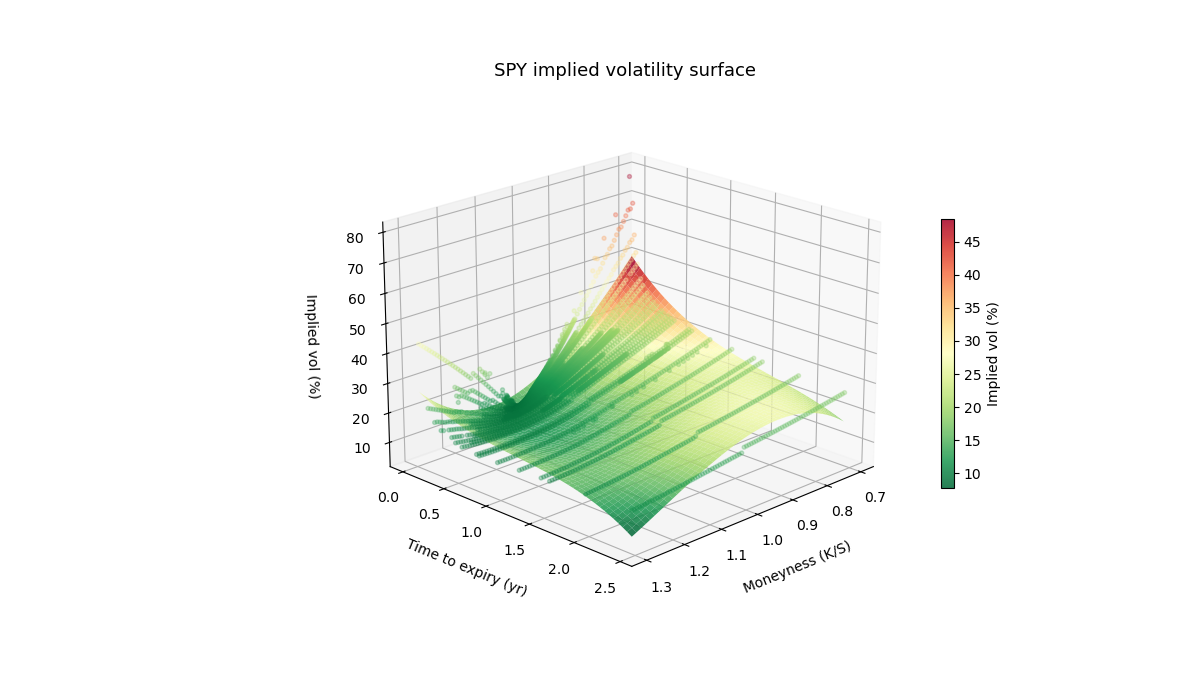

In [40]:
%matplotlib widget

from scipy.interpolate import griddata

otm = df_iv[
    ((df_iv["option_type"] == "call") & (df_iv["moneyness"] >= 1.0)) |
    ((df_iv["option_type"] == "put")  & (df_iv["moneyness"] <= 1.0))
].copy()

x = otm["moneyness"].values
y = otm["T"].values
z = otm["iv"].values * 100

moneyness_grid = np.linspace(x.min(), x.max(), 50)
T_grid         = np.linspace(y.min(), y.max(), 50)
M_grid, T_mesh = np.meshgrid(moneyness_grid, T_grid)

A = np.column_stack([
    np.ones_like(x),
    x, y,
    x**2, x*y, y**2,
    x**3, x**2*y, x*y**2, y**3
])
coeffs, _, _, _ = np.linalg.lstsq(A, z, rcond=None)

IV_fitted = (coeffs[0] +
             coeffs[1]*M_grid  + coeffs[2]*T_mesh +
             coeffs[3]*M_grid**2 + coeffs[4]*M_grid*T_mesh + coeffs[5]*T_mesh**2 +
             coeffs[6]*M_grid**3 + coeffs[7]*M_grid**2*T_mesh +
             coeffs[8]*M_grid*T_mesh**2 + coeffs[9]*T_mesh**3)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection="3d")

# polynomial surface — more opaque so it reads as the primary object
surf = ax.plot_surface(M_grid, T_mesh, IV_fitted,
                        cmap="RdYlGn_r", alpha=0.85,
                        linewidth=0, antialiased=True)

# raw scatter — more transparent so it reads as secondary reference points
sc = ax.scatter(x, y, z,
                c=z, cmap="RdYlGn_r",
                s=8, alpha=0.3, zorder=5)

ax.set_xlabel("Moneyness (K/S)", labelpad=10)
ax.set_ylabel("Time to expiry (yr)", labelpad=10)
ax.set_zlabel("Implied vol (%)", labelpad=10)
ax.set_title(f"{ticker} implied volatility surface", fontsize=13)
plt.colorbar(surf, ax=ax, shrink=0.5, label="Implied vol (%)")

ax.view_init(elev=20, azim=45)
plt.show()

In [43]:
plt.close('all') 
%matplotlib inline

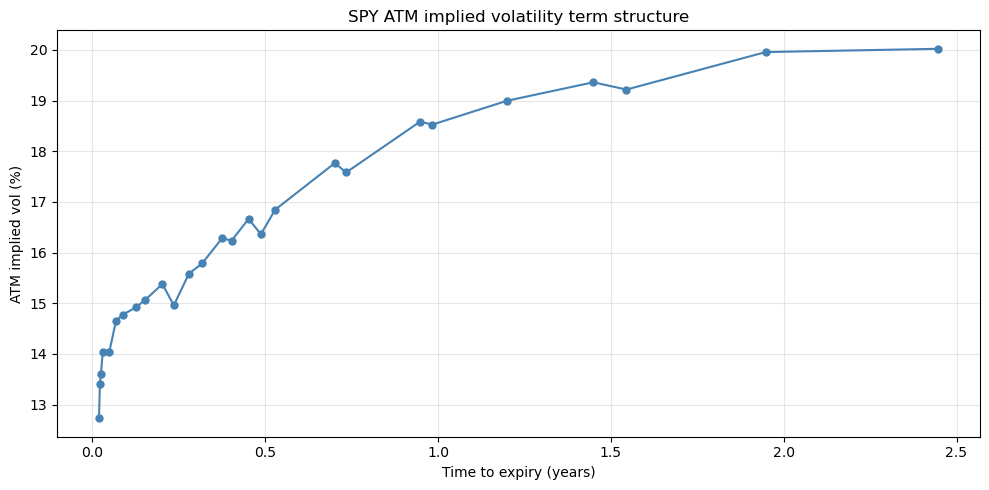


ATM implied vol by expiry:
    expiry        T    atm_iv
2026-07-13 0.019178 12.729347
2026-07-14 0.021918 13.413352
2026-07-15 0.024658 13.594448
2026-07-17 0.030137 14.041189
2026-07-24 0.049315 14.046590
2026-07-31 0.068493 14.653394
2026-08-07 0.087671 14.771107
2026-08-21 0.126027 14.917928
2026-08-31 0.153425 15.068883
2026-09-18 0.202740 15.378100
2026-09-30 0.235616 14.957318
2026-10-16 0.279452 15.583487
2026-10-30 0.317808 15.786145
2026-11-20 0.375342 16.282407
2026-11-30 0.402740 16.234567
2026-12-18 0.452055 16.662919
2026-12-31 0.487671 16.361031
2027-01-15 0.528767 16.845085
2027-03-19 0.701370 17.764799
2027-03-31 0.734247 17.580457
2027-06-17 0.947945 18.582140
2027-06-30 0.983562 18.524568
2027-09-17 1.200000 18.995724
2027-12-17 1.449315 19.359492
2028-01-21 1.545205 19.216212
2028-06-16 1.947945 19.955808
2028-12-15 2.446575 20.020343


In [42]:
# ATM vol for each expiry — moneyness closest to 1.0
atm_vols = []
for expiry in df_iv["expiry"].unique():
    subset = df_iv[df_iv["expiry"] == expiry]
    calls  = subset[subset["option_type"] == "call"]
    if len(calls) == 0:
        continue
    # find option with moneyness closest to 1.0
    atm_idx = (calls["moneyness"] - 1.0).abs().idxmin()
    atm_vols.append({
        "expiry": expiry,
        "T":      calls.loc[atm_idx, "T"],
        "atm_iv": calls.loc[atm_idx, "iv"] * 100
    })

atm_df = pd.DataFrame(atm_vols).sort_values("T")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(atm_df["T"], atm_df["atm_iv"],
        color="steelblue", marker="o", markersize=5, linewidth=1.5)
ax.set_xlabel("Time to expiry (years)")
ax.set_ylabel("ATM implied vol (%)")
ax.set_title(f"{ticker} ATM implied volatility term structure")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("vol_term_structure.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nATM implied vol by expiry:")
print(atm_df.to_string(index=False))

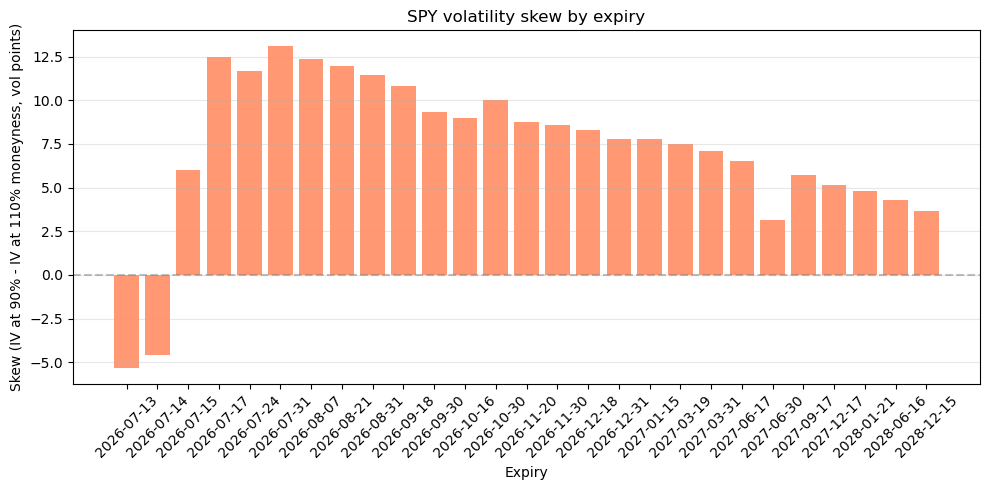


Skew by expiry (positive = downside puts more expensive):
    expiry        T      skew
2026-07-13 0.019178 -5.311068
2026-07-14 0.021918 -4.568948
2026-07-15 0.024658  5.981436
2026-07-17 0.030137 12.474683
2026-07-24 0.049315 11.693711
2026-07-31 0.068493 13.084421
2026-08-07 0.087671 12.371240
2026-08-21 0.126027 11.962960
2026-08-31 0.153425 11.465490
2026-09-18 0.202740 10.826988
2026-09-30 0.235616  9.347777
2026-10-16 0.279452  8.964577
2026-10-30 0.317808 10.000115
2026-11-20 0.375342  8.752760
2026-11-30 0.402740  8.569936
2026-12-18 0.452055  8.323170
2026-12-31 0.487671  7.755850
2027-01-15 0.528767  7.779825
2027-03-19 0.701370  7.497710
2027-03-31 0.734247  7.103117
2027-06-17 0.947945  6.513026
2027-06-30 0.983562  3.156710
2027-09-17 1.200000  5.723339
2027-12-17 1.449315  5.141805
2028-01-21 1.545205  4.803507
2028-06-16 1.947945  4.283568
2028-12-15 2.446575  3.638731


In [44]:
# measure skew as difference between 90% moneyness IV and 110% moneyness IV
# positive skew means lower strikes have higher IV (typical for equities)

skew_records = []
for expiry in df_iv["expiry"].unique():
    calls = df_iv[(df_iv["expiry"] == expiry) & 
                  (df_iv["option_type"] == "call")].sort_values("moneyness")
    if len(calls) < 5:
        continue

    # interpolate IV at moneyness 0.90 and 1.10
    try:
        iv_90  = np.interp(0.90, calls["moneyness"], calls["iv"])
        iv_110 = np.interp(1.10, calls["moneyness"], calls["iv"])
        skew   = (iv_90 - iv_110) * 100  # in vol points
        T_val  = calls["T"].iloc[0]
        skew_records.append({"expiry": expiry, "T": T_val, "skew": skew})
    except:
        continue

skew_df = pd.DataFrame(skew_records).sort_values("T")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(skew_df["expiry"], skew_df["skew"], color="coral", alpha=0.8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Expiry")
ax.set_ylabel("Skew (IV at 90% - IV at 110% moneyness, vol points)")
ax.set_title(f"{ticker} volatility skew by expiry")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("vol_skew.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSkew by expiry (positive = downside puts more expensive):")
print(skew_df.to_string(index=False))

## Observations

### Volatility smile and skew

All six expiries show a pronounced negative skew. Implied volatility rises as moneyness decreases below 1.0, meaning OTM puts are significantly more expensive than OTM calls at every expiry. 

Since the S&P 500 represents the broad US equity market, there's a couple of reasons for its skew:

*Demand for downside protection* — institutional investors such as pension funds, endowments, and mutual funds hold large long equity positions and systematically buy OTM puts to hedge against market drawdowns. SPY and SPX options are the most liquid and cheapest way to hedge a broad equity portfolio. So the excess demand drives up the price of low strike puts, pushing their implied vols higher than BSM would predict.

*Leverage effect* — when the S&P 500 falls, companies across the index become more leveraged as equity values drop while debt stays roughly fixed. Higher leverage makes equity riskier, so volatility rises when prices fall. This creates a negative correlation between SPY returns and volatility that BSM cannot model, and the market compensates by pricing low strike options with higher implied vol.

**Call IV anomalies**

The call IV curves in several expiries (particularly 2026-07-31 and 2026-08-31) show sharp spikes at specific strikes. These could be filtered out using tighter liquidity screens (minimum volume, maximum bid-ask spread as a percentage of mid-price). The put IV curves 
are much cleaner because OTM puts are far more actively traded than OTM calls for equity indices.

### Volatility skew by expiry

The skew bar chart shows a clear and consistent pattern. Skew declines monotonically from near-term to long-dated expiries:

- Near-term (July-August 2026): skew of ~11-13 vol points
- Medium-term (late 2026): skew of ~8-10 vol points  
- Longer-dated (2027-2028): skew declining to ~3-5 vol points

This pattern reflects the distributional argument discussed earlier. For the July 2026 expiry with T=0.03 years, the BSM distribution is extremely tight where a one standard deviation move is only about:

$$\sigma\sqrt{T} = 0.13 \times \sqrt{0.03} \approx 2.3\%$$

A strike at 90% moneyness is roughly 4 standard deviations away under BSM, but the market knows SPY can move 10% in a month during 
stress events, so it prices those puts far above BSM's estimate. The gap between BSM and market price is huge, producing a steep skew of around 12-13 vol points.

For the December 2028 expiry with T=2.45 years, a one standard deviation move is:

$$0.20 \times \sqrt{2.45} \approx 31\%$$

A strike at 90% moneyness is only 0.3 standard deviations away. BSM already assigns meaningful 
probability there, so the skew is only around 3-4 vol points.

### ATM implied volatility term structure

The term structure is upward sloping. ATM implied vol rises from 13.4% at the shortest expiry (T=0.03y, July 2026) to approximately 19.8% at the longest expiry (T=2.45y, December 2028). 

Near-term ATM vol of ~13-15% reflects the market's view of SPY volatility over the next few weeks to months under current conditions, which is relatively low by historical standards (SPY's long-run average volatility is roughly 15-20%).

Longer-term ATM vol of ~19-20% reflects the market's expectation that volatility will be higher on average over a multi-year horizon than it is right now. One reason for this is that volatility is mean-reverting. Since the current vol is below its long-run average, the market expects vol to drift back up toward its historical mean over time. Another reason is that over longer horizons there is more uncertainty 
about what the macroeconomic environment will look like. Hence, the market will price the uncertainty into the longer-term options. 

The term structure seems to flattens beyond T=1.5 years, which reflects when the vol approaches the long-run mean reversion level.

### Limitations

- Call IV spikes in several expiries reflect data quality issues from yfinance for illiquid OTM calls. To reduce anomalies, we could apply tighter liquidity filters.
- SPY pays quarterly dividends which reduce the effective forward price and affect implied vols, particularly for shorter expiries.